# Case 02 — Learning Curve chung minh **tran F1 ≈ 0.78**  ·  *Bai L6*

## Y tuong
Learning curve = huan luyen mo hinh voi **luong du lieu tang dan** (10%, 20%, ... 100% tap train),
moi lan do diem tren train va diem kiem dinh cheo (validation), roi ve 2 duong theo so mau.

## Vi sao chay thu nghiem nay
Ta ket luan F1 ~0.78 la **tran tu nhien** (do nhan co yeu to ngau nhien). Co mot phan bien hien nhien:
*"Hay tai IT du lieu qua? Them data thi F1 len chu?"*. Learning curve tra loi CHINH XAC cau nay.

## Cach doc
- Duong validation **phang som** roi khong tang -> **them du lieu vo ich** -> gioi han la
  **nhieu nhan (irreducible / tran Bayes)**, KHONG phai thieu data.
- Khoang cach train–val con lai = **phuong sai** khong the khu (variance).

In [1]:
# ============================================================================
# PRELUDE DUNG CHUNG cho moi notebook trong thu muc nay.
# Muc dich: moi file TU CHAY DUOC ma khong phu thuoc notebook chinh.
#   - Nap train.csv (Day chuyen A) + test.csv (Day chuyen B)
#   - Tao lai dung 4 feature co che nhu notebook chinh (de ket qua nhat quan)
# ============================================================================
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)   # co dinh seed -> chay lai ra so giong nhau

# --- Nap du lieu: thu nhieu duong dan vi notebook nam trong thu muc con ---
CANDIDATES = ['../Data_Final/Data_Final','../Data_Final','Data_Final/Data_Final',
              '../../Data_Final/Data_Final','Data_Final','.']
DATA_DIR = next((c for c in CANDIDATES
                 if os.path.exists(os.path.join(c,'train.csv'))
                 and os.path.exists(os.path.join(c,'test.csv'))), None)
assert DATA_DIR is not None, 'Khong tim thay train.csv/test.csv'
train = pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR,'test.csv'))

NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']  # 5 bien so goc
CAT = ['loai_san_pham','ca_lam_viec']   # 2 bien phan loai goc
TARGET = 'hong_hoc'                      # nhan: 1 = hong trong ca ke tiep

# --- Feature Engineering theo CO CHE vat ly (giong het notebook chinh) ---
def add_features(df):
    d = df.copy()
    # (1) Chenh lech nhiet: co che tan nhiet kem HDF. Lay HIEU nen triet tieu offset khi hau -> giam shift.
    d['chenh_lech_nhiet'] = d['nhiet_do_quy_trinh'] - d['nhiet_do_moi_truong']
    # (2) Cong suat co (W) = momen(Nm) * van_toc_goc(rad/s); van_toc_goc = rpm*2pi/60. Co che qua tai cong suat PWF.
    d['cong_suat_co']     = d['momen_xoan'] * d['toc_do_quay'] * 2*np.pi/60.0
    # (3) Tich mon*momen: co che qua tai cang thang OSF (mon cang nhieu + momen cang lon -> cang de gay).
    d['tich_mon_momen']   = d['do_mon_dao'] * d['momen_xoan']
    # (4) osf_margin: khoang cach toi NGUONG OSF, nguong phu thuoc HANG SP (L/M/H). >0 = da vuot nguong.
    g = d['loai_san_pham'].map({'L':11000,'M':12000,'H':13000})
    d['osf_margin']       = d['tich_mon_momen'] - g
    return d

train_fe = add_features(train); test_fe = add_features(test)
y_train = train_fe[TARGET].values
y_test  = test_fe[TARGET].values

# Bo feature CUOI da chot o notebook chinh: 9 bien so + 1 bien phan loai (loai_san_pham)
FINAL_NUM = NUM + ['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','osf_margin']
FINAL_CAT = ['loai_san_pham']
print('Train:', train.shape, '| Test:', test.shape,
      '| ti le hong train/test:', round(y_train.mean(),3), round(y_test.mean(),3))
print('FINAL_NUM =', FINAL_NUM)

Train: (14000, 8) | Test: (6000, 8) | ti le hong train/test: 0.074 0.08
FINAL_NUM = ['nhiet_do_moi_truong', 'nhiet_do_quy_trinh', 'toc_do_quay', 'momen_xoan', 'do_mon_dao', 'chenh_lech_nhiet', 'cong_suat_co', 'tich_mon_momen', 'osf_margin']


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve, StratifiedKFold

# Dung dung pipeline nhu mo hinh cuoi (RF + scale so + one-hot loai_san_pham)
pre = ColumnTransformer([('num', StandardScaler(), FINAL_NUM),
      ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), FINAL_CAT)])
rf  = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
pipe = Pipeline([('pre', pre), ('rf', rf)])
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)   # giu ty le lop trong moi fold

# scoring='average_precision' (AUC-PR): hop voi du lieu MAT CAN BANG hon la accuracy
# train_sizes: 8 moc tu 10% den 100% tap train
sizes, tr, val = learning_curve(pipe, train_fe[FINAL_NUM+FINAL_CAT], y_train, cv=skf,
                                scoring='average_precision',
                                train_sizes=np.linspace(0.1, 1.0, 8),
                                n_jobs=-1, random_state=RANDOM_STATE)
tr_m, val_m = tr.mean(1), val.mean(1)   # trung binh qua 5 fold

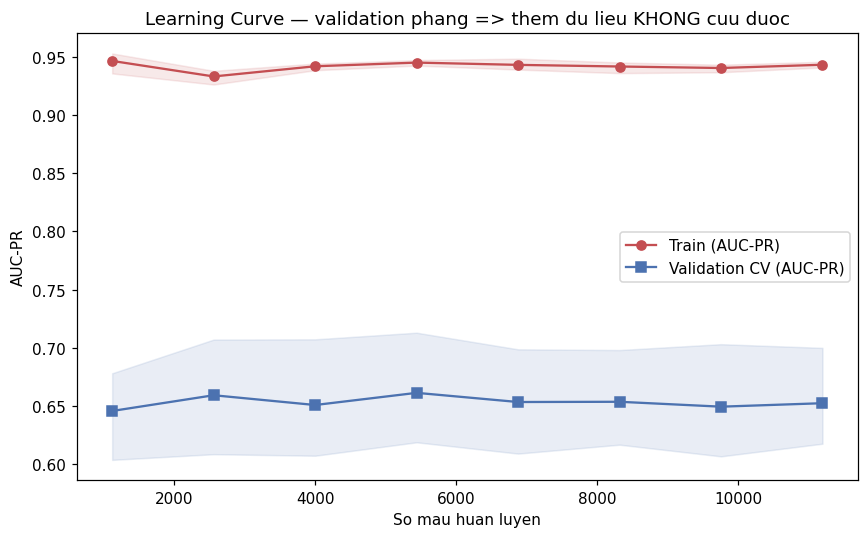

AUC-PR validation theo size: [0.646, 0.659, 0.651, 0.661, 0.653, 0.654, 0.649, 0.652]
Muc tang o NUA SAU cua duong validation = -0.0010  (gan 0 => da bao hoa)
Khoang cach Train - Val cuoi cung       = +0.291  (= phuong sai con lai)


In [3]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sizes, tr_m, 'o-', color='#C44E52', label='Train (AUC-PR)')
ax.fill_between(sizes, tr.min(1), tr.max(1), alpha=.12, color='#C44E52')   # dai bien do giua cac fold
ax.plot(sizes, val_m, 's-', color='#4C72B0', label='Validation CV (AUC-PR)')
ax.fill_between(sizes, val.min(1), val.max(1), alpha=.12, color='#4C72B0')
ax.set_xlabel('So mau huan luyen'); ax.set_ylabel('AUC-PR')
ax.set_title('Learning Curve — validation phang => them du lieu KHONG cuu duoc')
ax.legend(); plt.tight_layout(); plt.show()

print('AUC-PR validation theo size:', np.round(val_m,3).tolist())
delta = val_m[-1] - val_m[len(val_m)//2]     # muc tang o nua sau: gan 0 => da bao hoa
print(f'Muc tang o NUA SAU cua duong validation = {delta:+.4f}  (gan 0 => da bao hoa)')
print(f'Khoang cach Train - Val cuoi cung       = {tr_m[-1]-val_m[-1]:+.3f}  (= phuong sai con lai)')

> ### 🔎 Doc ket qua (Case 02)
> Diem validation theo luong data: `0.646 → 0.659 → 0.651 → 0.661 → 0.653 → 0.654 → 0.649 → 0.652`.
> - Duong val **di ngang tu rat som**; nua sau con giam nhe (Δ = −0.001) -> **da bao hoa**.
>   Cho an them du lieu, no khong nhich len.
> - Con lai mot khoang cach Train–Val (train cao hon) = **phuong sai**, dung ban chat cua rung cay.
>
> **Suy ra:** gioi han hieu nang **khong** do thieu du lieu, ma do **nhieu trong nhan (tran Bayes)**.
>
> ### ✅ Ket luan Case 02
> Day la **bang chung THU HAI, doc lap** voi lap luan resubstitution-vs-CV (F1 huan luyen lai = 1.0
> nhung CV chi ~0.76) o notebook nang cao F1. Hai bang chung cung chi ve mot ket luan:
> **F1 > 0.8 chi dat duoc neu RO RI du lieu (vi pham de bai)**.